# TEIS BDI-3 Analysis

[The Tennessee Early Intervention System (TEIS)](https://www.tn.gov/didd/for-consumers/tennessee-early-intervention-system-teis.html) is a voluntary program that offers therapy and other services to families of infants and young children with developmental delays or disabilities. Services are provided at no cost to families. TEIS is critically important to supporting the development of Tennessee children with disabilities and developmental delays as they prepare for school.

In this project, you are going to be working with data gathered from the Battelle Developmental Inventory, Third Edition (BDI-3) Eligibility Evaluation, an early childhood instrument based on the concept of developmental milestones. The BDI-3 is used by TEIS for determining eligibility and outcomes. This assessment tool has been in use for less than a year now, so the purpose of your work is to analyze the scores to see if there appear to be any weaknesses in this tool in any of the assessed domains or subdomains.

The BDI-3 is divided into 5 domains, each of which has 2 or 3 subdomains. On each domain and subdomain, a child receives several different scores. An example score report is available in the BDI3_ScoreReport.pdf file. See page 3 of this file for a detailed description of each score. Note that the BDI-3 is norm-based, meaning that the scores are generated by the child's performance based on the performance of same-aged peers on the same items. 

---------------------------------------------------------------------------------------------------------------------------------------------

# Some notes about the data:
* The same instrument is used for determining eligibility and outcomes. The type of evaluation can be determined from the "Program Label" column, which will indicate either an eligibility evaluation, an annual evaluation, or a birthday/milestone or exit evaluation. 
* Some of the rows are duplicated, so be sure to check that in your initial data inspection and cleaning. In addition, some children will have multiple rows in the dataset. A child is evaluated at initial eligibility, annually, and at their 3rd birthday or exit under certain circumstances. The evaluation may be repeated every 4 months (e.g. a child was ineligible and re-referred). 
* There are many records that are missing ID numbers. These records have been given a unique identifier which starts with "SP" so that they can be identified.
* When reading the data in, you may notice that some of the values in the RDI columns are incorrectly converted to dates. It is likely that this happens whenever the numerator of the fraction is 12 or less.


---------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import re

In [ ]:
df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\CBDI3_evals.csv', encoding='cp1252',  low_memory=False)
df

#### deleting the last 10, empty columns

In [ ]:
df = df.iloc[:, :-10]
df.copy()

#### cleaning the rdi columns

In [7]:
rdi_cols = df.columns[df.columns.str.endswith('RDI')]

for col in rdi_cols:
    df[col] = df[col].astype(str).str.replace('/90', '', regex=False)

df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI (out of 90),Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88,426.0,408 - 444,0,50.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6.0,15.0,95,6,>99,378.0,365 - 391,1.67,67.0,85
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,20.0,14.0,91,37,99,499.0,491 - 508,1.33,63.0,78
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,13.0,10.0,50,25,89,464.0,450 - 479,0,50.0,50
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,23.0,9.0,37,40,75,507.0,500 - 515,– 0.33,47.0,43


In [8]:
df.columns = [col + ' (out of 90)' if col in rdi_cols else col for col in df.columns]
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI (out of 90),Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88,426.0,408 - 444,0,50.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6.0,15.0,95,6,>99,378.0,365 - 391,1.67,67.0,85
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,20.0,14.0,91,37,99,499.0,491 - 508,1.33,63.0,78
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,13.0,10.0,50,25,89,464.0,450 - 479,0,50.0,50
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,23.0,9.0,37,40,75,507.0,500 - 515,– 0.33,47.0,43


In [9]:
month_prefixes = ('Jan-', 'Feb-', 'Mar-', 'Apr-', 'May-', 'Jun-',
                   'Jul-', 'Aug-', 'Sep-', 'Oct-', 'Nov-', 'Dec-')

def strip_month(val):
    val = str(val)
    if val.startswith(month_prefixes):
        return val[4:]
    return val

for col in rdi_cols:
    df[col] = df[col].apply(strip_month)

In [10]:
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI (out of 90),Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88,426.0,408 - 444,0,50.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6.0,15.0,95,6,>99,378.0,365 - 391,1.67,67.0,85
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,20.0,14.0,91,37,99,499.0,491 - 508,1.33,63.0,78
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,13.0,10.0,50,25,89,464.0,450 - 479,0,50.0,50
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,23.0,9.0,37,40,75,507.0,500 - 515,– 0.33,47.0,43


# Score Descriptors

### SS
Standard Score or Scale Score - Domain Standard Scores (SS), also called Developmental Quotients
(DQ), have a mean of 100 and standard deviation of 15. A Domain SS of 85 falls at the 16th percentile, 100 at the
50th, and a SS of 115 falls at the 84th percentile. Subdomain scaled scores have a mean of 10 and standard
deviation of 3. A scaled score of 7 falls at the 16th percentile, a scaled score of 10 falls at the 50th, and a scaled
score of 13 falls at the 84th percentile.
### PR
Percentile Rank scores reflect a child’s relative position within the normative sample for his or her age
group.
### Z-Score
A Z-Score is a score that is measured in terms of standard deviations from the average, or mean, and is
expressed as 0, positive numbers, or negative numbers. A Z-score of 0 falls at the mean.
### AE
Age Equivalent indicates the age at which a specific raw score is equal to the median (50th percentile)
obtained by children of a given age.
### CSS 
Change Sensitive Score the CSS represents a discrete point on the developmental milestone continuum
underlying each subdomain. The CSS scale is centered so that a score of 500 on each subdomain represents the
developmental level of a typical 36-month-old child and is best used to compare two administrations of the BDI-3
in order to assess change over time.
### RDI
The Relative Developmental Index (RDI) is expressed as a fraction, with the bottom number as 90, or 90%
proficiency for the examinee’s age group. The numerator is a number ranging from 0 to 100 and expresses the
examinee’s proficiency.
### T-Score
A T-Score is a score that has a mean of 50 and a standard deviation of 10.
### NCE
The Normal Curve Equivalent is another commonly reported type of standard score that has a mean of 50
and a standard deviation of 21.06.

# Project Objectives

# 1. In which domains (and sub-domains) are children performing highest and lowest?

In [11]:
dq = df[df.columns[df.columns.str.endswith('Developmental Quotient')]]

dq.astype('int32', errors='ignore')


,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient,BDI-3 Total Developmental Quotient
0,85.0,127.0,91.0,88.0,100.0,99.0
1,88.0,104.0,97.0,102.0,100.0,99.0
2,90.0,91.0,82.0,109.0,83.0,89.0
3,115.0,103.0,88.0,91.0,113.0,101.0
4,75.0,73.0,70.0,73.0,97.0,71.0
...,...,...,...,...,...,...
23942,115.0,115.0,112.0,118.0,113.0,119.0
23943,115.0,116.0,112.0,117.0,122.0,119.0
23944,103.0,102.0,55.0,104.0,98.0,94.0
23945,88.0,90.0,76.0,100.0,88.0,88.0


- Isolating the developmental quotient columns

In [12]:
dq.describe()

,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient,BDI-3 Total Developmental Quotient
count,23939.000000,23927.000000,23912.000000,23912.000000,23926.000000,23880.000000
mean,86.988304,94.293601,79.060723,93.875711,88.412188,87.216332
std,17.689509,16.819322,20.417259,17.731262,16.620340,17.178270
min,46.000000,46.000000,46.000000,42.000000,40.000000,40.000000
25%,76.000000,84.000000,64.000000,83.000000,78.000000,76.000000
50%,88.000000,94.000000,79.000000,96.000000,90.000000,88.000000
75%,100.000000,106.000000,94.000000,106.000000,100.000000,99.000000
max,148.000000,154.000000,154.000000,154.000000,160.000000,160.000000


### Domain Performance
- Children are performing highest in Social-Emotional and Motor catagories, with an average close to the 100 mark. They also have slightly lower stanard deviations, representing a less spread out range of scores.

- On the other hand, children asssesed for the Communication catagory score lower on average, at 79. In addition, a std score of 20.4 represents a more spread out, wide range of scores across all children assessed.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

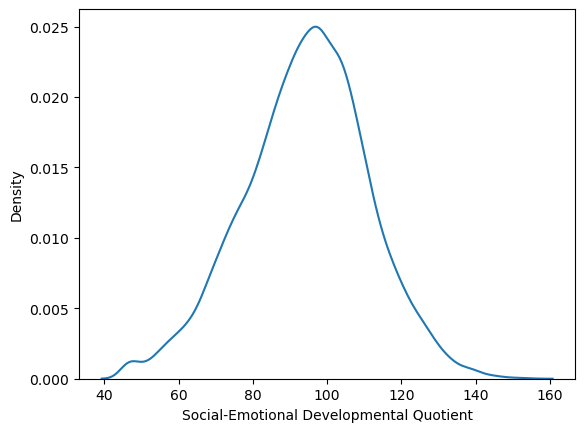

In [14]:
SE_plot = sns.kdeplot(data=dq, x='Social-Emotional Developmental Quotient')
SE_plot.figure.savefig('my_plot1.jpg') 

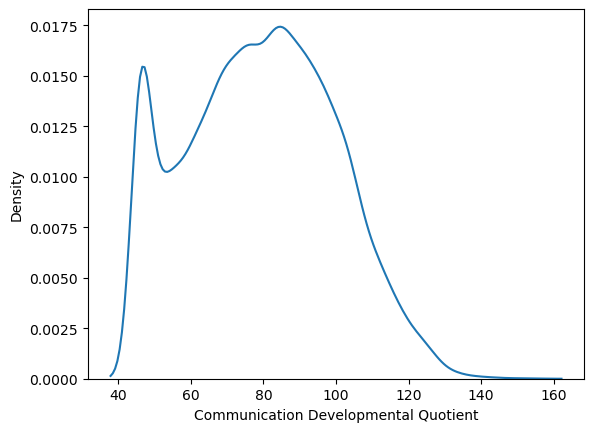

In [15]:
communication_plot = sns.kdeplot(data=dq, x='Communication Developmental Quotient')
communication_plot
communication_plot.figure.savefig('my_plot2.jpg') 

- to look at subdomains, we use the Scaled Score (SS). a score of 10 repesents a typical score for the student based on their age. 

In [16]:
# sd= df[df.columns[df.columns.str.endswith(' SS')]]

# sd

In [17]:
ss_cols= df[df.columns[df.columns.str.endswith(' SS')]]
sd = df[['Child ID'] + list(ss_cols)]
sd_clean = sd[[
    'Child ID','Adaptive-Self Care SS', 
    'Adaptive-Personal Responsibility SS', 
    'Communication-Receptive Communication SS',
    'Communication-Expressive Communication SS',
    'Social Emotional-Adult Interaction SS',
    'Social Emotional-Peer Interaction SS',
    'Social Emotional-Self Concept / Social Role SS',
    'Motor-Fine Motor SS',
    'Motor-Perceptual Motor SS',
    'Cognitive-Attention and Memory SS',
    'Cognitive-Reasoning / Academic Skills SS',
    'Cognitive-Perception and Concepts SS']]

In [18]:
sd_clean

,Child ID,Adaptive-Self Care SS,Adaptive-Personal Responsibility SS,Communication-Receptive Communication SS,Communication-Expressive Communication SS,Social Emotional-Adult Interaction SS,Social Emotional-Peer Interaction SS,Social Emotional-Self Concept / Social Role SS,Motor-Fine Motor SS,Motor-Perceptual Motor SS,Cognitive-Attention and Memory SS,Cognitive-Reasoning / Academic Skills SS,Cognitive-Perception and Concepts SS
0,44879,7.0,NaN,8.0,9.0,14.0,NaN,15.0,9.0,NaN,7.0,NaN,13.0
1,47795,7.0,9.0,10.0,9.0,12.0,9.0,11.0,13.0,11.0,9.0,14.0,7.0
2,54340,8.0,NaN,7.0,7.0,11.0,NaN,6.0,12.0,NaN,8.0,NaN,7.0
3,54344,13.0,NaN,8.0,8.0,10.0,NaN,11.0,12.0,NaN,14.0,NaN,10.0
4,54515,5.0,NaN,5.0,5.0,6.0,NaN,5.0,8.0,NaN,9.0,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,13.0,NaN,12.0,12.0,13.0,NaN,12.0,15.0,NaN,9.0,NaN,15.0
23943,SP03288,10.0,15.0,14.0,10.0,12.0,13.0,13.0,11.0,12.0,13.0,14.0,14.0
23944,SP03289,10.0,11.0,4.0,1.0,12.0,10.0,9.0,10.0,11.0,10.0,9.0,10.0
23945,SP03290,6.0,10.0,7.0,5.0,8.0,11.0,6.0,10.0,11.0,7.0,8.0,9.0


In [19]:
sd_clean.describe()

,Adaptive-Self Care SS,Adaptive-Personal Responsibility SS,Communication-Receptive Communication SS,Communication-Expressive Communication SS,Social Emotional-Adult Interaction SS,Social Emotional-Peer Interaction SS,Social Emotional-Self Concept / Social Role SS,Motor-Fine Motor SS,Motor-Perceptual Motor SS,Cognitive-Attention and Memory SS,Cognitive-Reasoning / Academic Skills SS,Cognitive-Perception and Concepts SS
count,23940.000000,13139.000000,23931.000000,23915.000000,23935.000000,13134.000000,23931.000000,23925.000000,13126.000000,23929.000000,13133.000000,23927.000000
mean,7.324854,8.023289,6.634700,6.386912,10.476332,7.858002,7.985584,9.670805,8.549520,8.310377,8.074317,7.619133
std,3.149402,3.931179,3.650991,3.703074,2.860787,3.330956,3.277486,3.257990,3.958829,2.729118,3.241116,3.284079
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,6.000000,5.000000,4.000000,4.000000,9.000000,5.000000,6.000000,8.000000,6.000000,7.000000,6.000000,6.000000
50%,7.000000,8.000000,7.000000,6.000000,11.000000,8.000000,8.000000,10.000000,9.000000,9.000000,8.000000,8.000000
75%,9.000000,11.000000,9.000000,9.000000,12.000000,10.000000,10.000000,12.000000,11.000000,10.000000,11.000000,10.000000
max,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000


### Highest subdomain: adult interaction (s-e)
- In fact, adult interaction (sel domain) was higher on average compared to the general population.


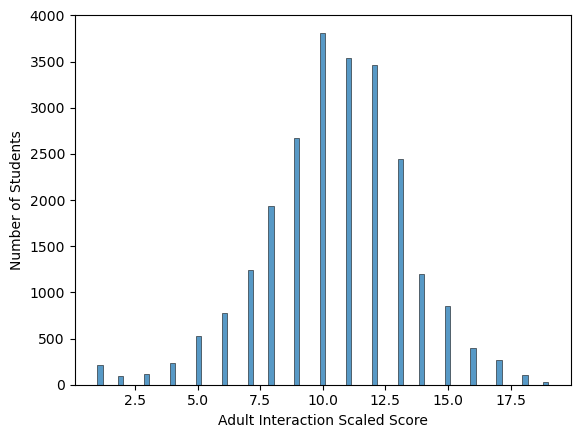

In [20]:
adult_interaction = sns.histplot(data=sd_clean, x = 'Social Emotional-Adult Interaction SS')
plt.xlabel("Adult Interaction Scaled Score")
plt.ylabel("Number of Students")
plt.show()
adult_interaction.figure.savefig('adult_interaction_plot.jpg')

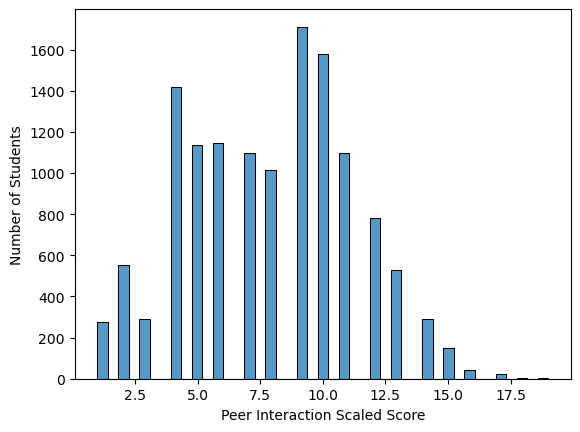

In [21]:
peer_interaction = sns.histplot(data=sd_clean, x = 'Social Emotional-Peer Interaction SS')
plt.xlabel("Peer Interaction Scaled Score")
plt.ylabel("Number of Students")
plt.show()
peer_interaction.figure.savefig('peer_interaction_plot.jpg')

### Lowest subomain: expressive communication

- a std deviation of 3.7 shows there is a wide spread of scores

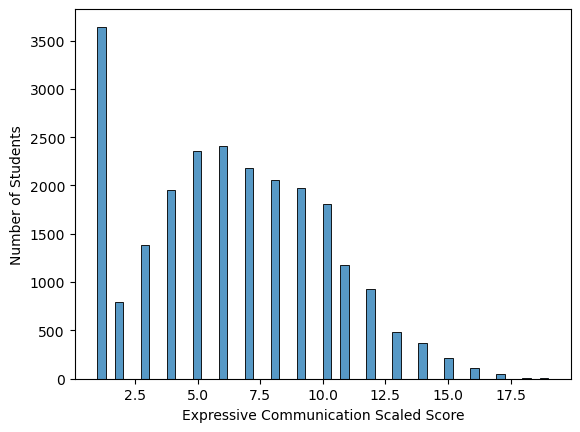

In [22]:
expressive = sns.histplot(data=sd_clean, x = 'Communication-Expressive Communication SS')
plt.ylabel("Number of Students")
plt.xlabel("Expressive Communication Scaled Score")
plt.show()

# 2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [23]:
domain_cols = df.columns[df.columns.str.endswith('Developmental Quotient')]

- create list of domain columns

In [24]:
df['Average Domain Score'] = df[domain_cols].mean(axis=1)

- finding the average of an indidvidual's domain score row-wise (axis=1)

In [25]:
df['Average Domain Score'] = df['Average Domain Score'].round(1)

- rounding for aggregation

In [26]:
df['Standard Deviation Domain Score']= df[domain_cols].std(axis=1)

- repeat process for standard dev and range

In [27]:
df['Standard Deviation Domain Score'] = df['Standard Deviation Domain Score'].round(1)

In [28]:
df['Range Domain Score'] = df[domain_cols].max(axis=1) - df[domain_cols].min(axis=1)

In [29]:
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI (out of 90),Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Average Domain Score,Standard Deviation Domain Score,Range Domain Score
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,12,98,411.0,392 - 431,1,60.0,71,98.3,15.3,42.0
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,18,29,437.0,421 - 453,– 1.00,40.0,29,98.3,5.6,16.0
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,15,37,426.0,408 - 444,– 1.00,40.0,29,90.7,9.7,27.0
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,12,92,411.0,392 - 431,0,50.0,50,101.8,11.0,27.0
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,15,88,426.0,408 - 444,0,50.0,50,76.5,10.2,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6,>99,378.0,365 - 391,1.67,67.0,85,115.3,2.7,7.0
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,37,99,499.0,491 - 508,1.33,63.0,78,116.8,3.4,10.0
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,25,89,464.0,450 - 479,0,50.0,50,92.7,18.8,49.0
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,40,75,507.0,500 - 515,– 0.33,47.0,43,88.3,7.6,24.0


In [30]:
df[['Range Domain Score','Standard Deviation Domain Score','Average Domain Score' ]].describe()

,Range Domain Score,Standard Deviation Domain Score,Average Domain Score
count,23943.000000,23938.000000,23943.000000
mean,29.906236,10.846950,88.313474
std,11.611245,4.048296,15.190207
min,0.000000,0.000000,44.300000
25%,21.000000,7.900000,79.000000
50%,29.000000,10.600000,89.700000
75%,37.000000,13.500000,99.000000
max,87.000000,32.900000,154.500000


-see overview of new df

array([[<Axes: title={'center': 'Range Domain Score'}>,
        <Axes: title={'center': 'Standard Deviation Domain Score'}>],
       [<Axes: title={'center': 'Average Domain Score'}>, <Axes: >]],
      dtype=object)

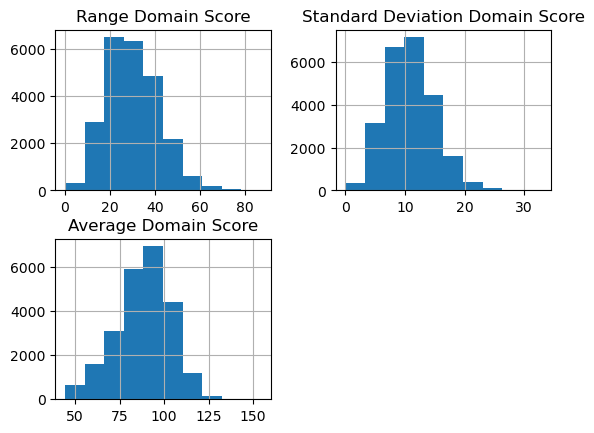

In [31]:
df[['Range Domain Score','Standard Deviation Domain Score','Average Domain Score' ]].hist()

In [32]:
df[['Standard Deviation Domain Score','Average Domain Score' ]].corr()

,Standard Deviation Domain Score,Average Domain Score
Standard Deviation Domain Score,1.000000,-0.091572
Average Domain Score,-0.091572,1.000000


In [33]:
plot_df = df.groupby(['Standard Deviation Domain Score', 'Average Domain Score']).size().reset_index(name='count')

-create hexbin to sort individual records (# of total assessments)

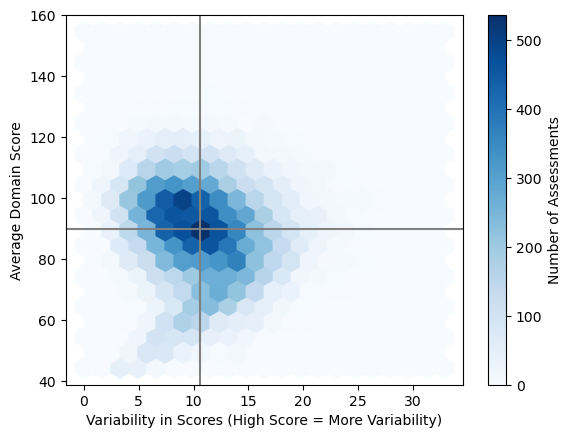

In [34]:
avg_var = plt.hexbin(df['Standard Deviation Domain Score'], 
           df['Average Domain Score'], 
           gridsize=20, cmap='Blues')
plt.colorbar(label='Number of Assessments')
plt.xlabel('Variability in Scores (High Score = More Variability)')
plt.ylabel('Average Domain Score')
plt.axhline(df['Average Domain Score'].median(), color='gray', linestyle='-', alpha=1)
plt.axvline(df['Standard Deviation Domain Score'].median(), color='gray', linestyle='-', alpha=1)
plt.show()
avg_var.figure.savefig('avg_var.jpg')

# 3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

-join domain and subdomain columns into a list

In [35]:
domain_cols = df.columns[df.columns.str.endswith('Developmental Quotient')]
subdomain_cols = df.columns[df.columns.str.endswith(' SS')]

all_cols = subdomain_cols.tolist() + domain_cols.tolist()
all_cols

['Adaptive-Self Care SS',
 'Adaptive-Personal Responsibility SS',
 'Social Emotional-Adult Interaction SS',
 'Social Emotional-Peer Interaction SS',
 'Social Emotional-Self Concept / Social Role SS',
 'Communication-Receptive Communication SS',
 'Communication-Expressive Communication SS',
 'Motor-Gross Motor SS',
 'Motor-Fine Motor SS',
 'Motor-Perceptual Motor SS',
 'Cognitive-Attention and Memory SS',
 'Cognitive-Reasoning / Academic Skills SS',
 'Cognitive-Perception and Concepts SS',
 'Adaptive Developmental Quotient',
 'Social-Emotional Developmental Quotient',
 'Communication Developmental Quotient',
 'Motor Developmental Quotient',
 'Cognitive Developmental Quotient',
 'BDI-3 Total Developmental Quotient']

-from that list, pull all subdomains into their domain and convert to df 

In [36]:
adaptive = [col for col in all_cols if col.startswith('Adaptive')]
adaptive_df = df[adaptive]

In [37]:
adaptive_df.describe()

,Adaptive-Self Care SS,Adaptive-Personal Responsibility SS,Adaptive Developmental Quotient
count,23940.000000,13139.000000,23939.000000
mean,7.324854,8.023289,86.988304
std,3.149402,3.931179,17.689509
min,1.000000,1.000000,46.000000
25%,6.000000,5.000000,76.000000
50%,7.000000,8.000000,88.000000
75%,9.000000,11.000000,100.000000
max,19.000000,19.000000,148.000000


In [38]:
social_emotional = [col for col in all_cols if col.startswith('Social')]
social_emotional_df = df[social_emotional]

In [39]:
social_emotional_df.describe()

,Social Emotional-Adult Interaction SS,Social Emotional-Peer Interaction SS,Social Emotional-Self Concept / Social Role SS,Social-Emotional Developmental Quotient
count,23935.000000,13134.000000,23931.000000,23927.000000
mean,10.476332,7.858002,7.985584,94.293601
std,2.860787,3.330956,3.277486,16.819322
min,1.000000,1.000000,1.000000,46.000000
25%,9.000000,5.000000,6.000000,84.000000
50%,11.000000,8.000000,8.000000,94.000000
75%,12.000000,10.000000,10.000000,106.000000
max,19.000000,19.000000,19.000000,154.000000


In [40]:
communication = [col for col in all_cols if col.startswith('Communication')]
communication_df = df[communication]

In [41]:
communication_df.describe()

,Communication-Receptive Communication SS,Communication-Expressive Communication SS,Communication Developmental Quotient
count,23931.000000,23915.000000,23912.000000
mean,6.634700,6.386912,79.060723
std,3.650991,3.703074,20.417259
min,1.000000,1.000000,46.000000
25%,4.000000,4.000000,64.000000
50%,7.000000,6.000000,79.000000
75%,9.000000,9.000000,94.000000
max,19.000000,19.000000,154.000000


In [42]:
cognitive = [col for col in all_cols if col.startswith('Cognitive')]
cognitive_df = df[cognitive]

In [43]:
cognitive_df.describe()

,Cognitive-Attention and Memory SS,Cognitive-Reasoning / Academic Skills SS,Cognitive-Perception and Concepts SS,Cognitive Developmental Quotient
count,23929.000000,13133.000000,23927.000000,23926.000000
mean,8.310377,8.074317,7.619133,88.412188
std,2.729118,3.241116,3.284079,16.620340
min,1.000000,1.000000,1.000000,40.000000
25%,7.000000,6.000000,6.000000,78.000000
50%,9.000000,8.000000,8.000000,90.000000
75%,10.000000,11.000000,10.000000,100.000000
max,19.000000,19.000000,19.000000,160.000000


In [44]:
motor = [col for col in all_cols if col.startswith('Motor')]
motor_df = df[motor]

In [45]:
motor_df.describe()

,Motor-Gross Motor SS,Motor-Fine Motor SS,Motor-Perceptual Motor SS,Motor Developmental Quotient
count,23927.000000,23925.000000,13126.000000,23912.000000
mean,8.510260,9.670805,8.549520,93.875711
std,3.064843,3.257990,3.958829,17.731262
min,1.000000,1.000000,1.000000,42.000000
25%,7.000000,8.000000,6.000000,83.000000
50%,9.000000,10.000000,9.000000,96.000000
75%,11.000000,12.000000,11.000000,106.000000
max,19.000000,19.000000,19.000000,154.000000


# 4. Does the child's age seem to impact their scoring?

+ I want to determine the childs age at the time of the test, but first I want to make sure the date of testing is the same for each person

In [46]:
date = df[df.columns[df.columns.str.endswith('Date of Testing')]]

- find all the columns that list the testing date

In [47]:
date_cols = ['Adaptive-Self Care Date of Testing', 
             'Adaptive-Personal Responsibility Date of Testing', 
             'Social Emotional-Adult Interaction Date of Testing',
             'Social Emotional-Peer Interaction Date of Testing',
             'Social Emotional-Self Concept / Social Role Date of Testing',
             'Communication-Receptive Communication Date of Testing',
             'Communication-Expressive Communication Date of Testing',
             'Motor-Gross Motor Date of Testing',
             'Motor-Fine Motor Date of Testing',
             'Motor-Perceptual Motor Date of Testing',
             'Cognitive-Attention and Memory Date of Testing',
             'Cognitive-Reasoning / Academic Skills Date of Testing',
             'Cognitive-Perception and Concepts Date of Testing']

date_cols

['Adaptive-Self Care Date of Testing',
 'Adaptive-Personal Responsibility Date of Testing',
 'Social Emotional-Adult Interaction Date of Testing',
 'Social Emotional-Peer Interaction Date of Testing',
 'Social Emotional-Self Concept / Social Role Date of Testing',
 'Communication-Receptive Communication Date of Testing',
 'Communication-Expressive Communication Date of Testing',
 'Motor-Gross Motor Date of Testing',
 'Motor-Fine Motor Date of Testing',
 'Motor-Perceptual Motor Date of Testing',
 'Cognitive-Attention and Memory Date of Testing',
 'Cognitive-Reasoning / Academic Skills Date of Testing',
 'Cognitive-Perception and Concepts Date of Testing']

- convert date_cols to MM/DD/YYYY format

In [48]:
df[date_cols] = df[date_cols].apply(pd.to_datetime, format='%m/%d/%Y')

In [49]:
print(df[date_cols])

      Adaptive-Self Care Date of Testing  \
0                             2023-06-23   
1                             2023-03-21   
2                             2023-04-06   
3                             2023-02-23   
4                             2023-02-24   
...                                  ...   
23942                         2023-11-15   
23943                         2023-11-13   
23944                         2023-11-14   
23945                         2023-10-26   
23946                         2023-10-24   

      Adaptive-Personal Responsibility Date of Testing  \
0                                                  NaT   
1                                           2023-03-21   
2                                                  NaT   
3                                                  NaT   
4                                                  NaT   
...                                                ...   
23942                                              NaT   
23943  

- using row_check to look across each row (axis=1 checks across rows)

In [50]:
row_check = df[date_cols].nunique(axis=1) == 1
row_check

0        True
1        True
2        True
3        True
4        True
         ... 
23942    True
23943    True
23944    True
23945    True
23946    True
Length: 23947, dtype: bool

In [51]:
check_dates = df[date_cols].nunique(axis=1)
check_dates

0        1
1        1
2        1
3        1
4        1
        ..
23942    1
23943    1
23944    1
23945    1
23946    1
Length: 23947, dtype: int64

- my "inconsistant_dates" df returns rows where the test took place over multiple days 

In [52]:
inconsistant_dates = df[check_dates > 1]

In [53]:
inconsistant_dates[date_cols].reset_index()

,index,Adaptive-Self Care Date of Testing,Adaptive-Personal Responsibility Date of Testing,Social Emotional-Adult Interaction Date of Testing,Social Emotional-Peer Interaction Date of Testing,Social Emotional-Self Concept / Social Role Date of Testing,Communication-Receptive Communication Date of Testing,Communication-Expressive Communication Date of Testing,Motor-Gross Motor Date of Testing,Motor-Fine Motor Date of Testing,Motor-Perceptual Motor Date of Testing,Cognitive-Attention and Memory Date of Testing,Cognitive-Reasoning / Academic Skills Date of Testing,Cognitive-Perception and Concepts Date of Testing
0,426,2023-08-23,2023-08-23,2023-08-23,2023-08-23,2023-08-23,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31
1,427,2023-08-23,2023-08-23,2023-08-23,2023-08-23,2023-08-23,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31,2023-07-31
2,1928,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-02-23,2023-03-16,2023-02-23,2023-02-23
3,2999,2023-09-07,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06
4,3000,2023-09-07,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06,2023-09-06
5,3055,2023-10-20,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19,2023-10-19
6,3570,2023-11-07,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02,2023-11-02
7,4808,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-07,2023-08-08,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02
8,4809,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-07,2023-08-08,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02,2023-08-02
9,6786,2023-10-13,2023-10-13,2023-10-13,2023-10-13,2023-10-13,2023-10-13,2023-10-13,2023-10-30,2023-10-30,2023-10-30,2023-10-30,2023-10-30,2023-10-30


- 46 entries, great! It's not too big of a problem. all of these were within a month, so I will keep these in mind.

- 46 out of 23947 is only 0.19%, so i'm just going to ignore those rows for now.

- Next, we're just going to pull the date from the date cols where all sections of the test happened on the same day

In [54]:
df['Test Date'] = df[date_cols].min(axis=1)
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RDI (out of 90),Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Average Domain Score,Standard Deviation Domain Score,Range Domain Score,Test Date
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,98,411.0,392 - 431,1,60.0,71,98.3,15.3,42.0,2023-06-23
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,29,437.0,421 - 453,– 1.00,40.0,29,98.3,5.6,16.0,2023-03-21
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,37,426.0,408 - 444,– 1.00,40.0,29,90.7,9.7,27.0,2023-04-06
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,92,411.0,392 - 431,0,50.0,50,101.8,11.0,27.0,2023-02-23
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,88,426.0,408 - 444,0,50.0,50,76.5,10.2,27.0,2023-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,>99,378.0,365 - 391,1.67,67.0,85,115.3,2.7,7.0,2023-11-15
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,99,499.0,491 - 508,1.33,63.0,78,116.8,3.4,10.0,2023-11-13
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,89,464.0,450 - 479,0,50.0,50,92.7,18.8,49.0,2023-11-14
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,75,507.0,500 - 515,– 0.33,47.0,43,88.3,7.6,24.0,2023-10-26


> check datatype of dob

In [55]:
print(df['Date of Birth'].dtype)

object


> reformat dob to datetime

In [56]:
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], format='%m/%d/%Y')

> make a new age column where (test date - dob = age)

In [57]:
# df['Age (Days)'] = df['Test Date'] - df['Date of Birth']

# df

> Interesting! It seems like it automatically computes their age in days by default

> Since we're doing EI work, they probably want it in months...

In [58]:
df['Age (Months)'] = (
    (df['Test Date'].dt.year - df['Date of Birth'].dt.year) * 12 +
    (df['Test Date'].dt.month - df['Date of Birth'].dt.month) -
    (df['Test Date'].dt.day < df['Date of Birth'].dt.day)
)

df.copy()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Average Domain Score,Standard Deviation Domain Score,Range Domain Score,Test Date,Age (Months)
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,411.0,392 - 431,1,60.0,71,98.3,15.3,42.0,2023-06-23,8.0
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,437.0,421 - 453,– 1.00,40.0,29,98.3,5.6,16.0,2023-03-21,26.0
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,426.0,408 - 444,– 1.00,40.0,29,90.7,9.7,27.0,2023-04-06,21.0
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,411.0,392 - 431,0,50.0,50,101.8,11.0,27.0,2023-02-23,11.0
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,426.0,408 - 444,0,50.0,50,76.5,10.2,27.0,2023-02-24,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,2023-09-25,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,378.0,365 - 391,1.67,67.0,85,115.3,2.7,7.0,2023-11-15,1.0
23943,SP03288,F,2021-05-18,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,499.0,491 - 508,1.33,63.0,78,116.8,3.4,10.0,2023-11-13,29.0
23944,SP03289,F,2021-10-31,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,464.0,450 - 479,0,50.0,50,92.7,18.8,49.0,2023-11-14,24.0
23945,SP03290,M,2020-03-25,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,507.0,500 - 515,– 0.33,47.0,43,88.3,7.6,24.0,2023-10-26,43.0


> Now theres two new columns: 'Test Date' and 'Age (Months)'

In [59]:
age_dq = df.columns[df.columns.str.endswith('Developmental Quotient')].tolist() 

>age_dq holds the DQ column names

In [60]:
df['Average Score'] = df[age_dq].mean(axis=1)

>finding the mean of average score row-wise (axis=1)

In [61]:
df[['Average Score', 'Age (Months)']]

,Average Score,Age (Months)
0,98.333333,8.0
1,98.333333,26.0
2,90.666667,21.0
3,101.833333,11.0
4,76.500000,15.0
...,...,...
23942,115.333333,1.0
23943,116.833333,29.0
23944,92.666667,24.0
23945,88.333333,43.0


> new df with just avg score and age of individual

In [62]:
 df.groupby('Age (Months)')['Average Score'].mean()

Age (Months)
0.0     103.030333
1.0     101.938143
2.0      96.337825
3.0      93.364555
4.0      92.419263
5.0      92.779647
6.0      93.675991
7.0      94.181293
8.0      94.469444
9.0      95.043948
10.0     93.729616
11.0     93.300147
12.0     96.804126
13.0     94.007179
14.0     93.266284
15.0     92.214210
16.0     91.063970
17.0     90.337062
18.0     91.535700
19.0     90.516275
20.0     88.250285
21.0     86.726554
22.0     85.101852
23.0     84.119600
24.0     86.868466
25.0     87.747396
26.0     89.531566
27.0     84.920624
28.0     85.256571
29.0     85.955645
30.0     83.490705
31.0     84.195712
32.0     85.972185
33.0     82.977303
34.0     83.320513
35.0     86.198162
36.0     83.165410
37.0     82.865741
38.0     83.060516
39.0     81.093992
40.0     81.728543
41.0     81.717105
42.0     81.958995
43.0     80.072917
44.0     83.127451
45.0     81.152047
46.0     89.258333
47.0     87.157407
48.0    105.500000
Name: Average Score, dtype: float64

>group all all ages month wise to find avg per age

In [63]:
 df.groupby('Age (Months)')

In [64]:
avg_dq_age = df.groupby('Age (Months)', as_index=False)['Average Score'].agg(['mean', 'count'])

>create a count of each indivual per age group bucket 

In [65]:
avg_dq_age

,Age (Months),mean,count
0,0.0,103.030333,250
1,1.0,101.938143,551
2,2.0,96.337825,538
3,3.0,93.364555,363
4,4.0,92.419263,321
5,5.0,92.779647,208
6,6.0,93.675991,286
7,7.0,94.181293,245
8,8.0,94.469444,180
9,9.0,95.043948,347


>plot

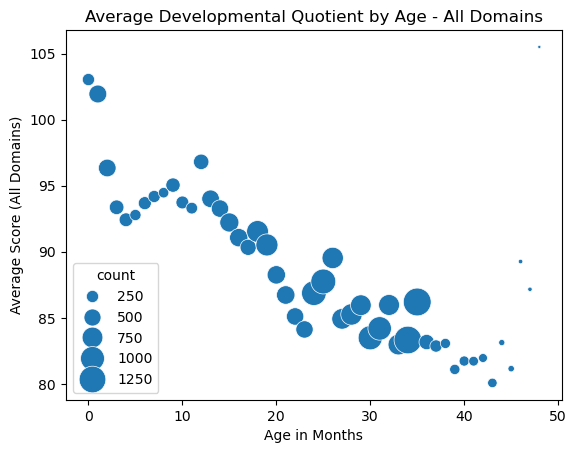

In [66]:
dq_age_plot = sns.scatterplot(
    data = avg_dq_age,
    x = 'Age (Months)',
    y = "mean",
    size = 'count',
    sizes=(5,400))
plt.xlabel("Age in Months")
plt.ylabel("Average Score (All Domains)")
plt.title("Average Developmental Quotient by Age - All Domains")
plt.show()

dq_age_plot.figure.savefig('dq_average_by_age_plot.jpg')

In [67]:
# dq_age_plot = sns.lineplot(data=avg_dq_age, x = 'Age (Months)', y = 'Average Score')
# plt.xlabel("Age in Months")
# plt.ylabel("Average Score (All Domains)")
# plt.show()

# 5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

# 6. Is there any difference in scoring noted based on evaluation type?

eligibility evaluations typically have higher overall scores compared to annual evaluations.
Annual evaluations typically have higher stdev (more heterogeneity) 

In [68]:
adaptive_info = df.groupby('Program Label')[['Adaptive Developmental Quotient']].describe()
adaptive_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Adaptive Developmental Quotient             \
                                                             count       mean   
Program Label                                                                   
BDI-3 Eligibility Evaluation                               12397.0  89.184238   
BDI-3 Annual Evaluation                                    11203.0  84.604570   
BDI-3 Milestone or Exit Evaluation                           339.0  85.460177   

                                                                               
                                          std   min   25%   50%    75%    max  
Program Label                                                                  
BDI-3 Eligibility Evaluation        16.454346  46.0  80.0  90.0  100.0  148.0  
BDI-3 Annual Evaluation             18.617865  46.0  73.0  85.0   97.0  148.0  
BDI-3 Milestone or Exit Evaluation  19.411932  46.0  73.0  85.0  100.0  133.0

In [69]:
se_info = df.groupby('Program Label')[['Social-Emotional Developmental Quotient']].describe()

In [70]:
se_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Social-Emotional Developmental Quotient  \
                                                                     count   
Program Label                                                                
BDI-3 Eligibility Evaluation                                       12395.0   
BDI-3 Annual Evaluation                                            11193.0   
BDI-3 Milestone or Exit Evaluation                                   339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        95.432432  16.404820  46.0  85.0  97.0   
BDI-3 Annual Evaluation             93.072099  17.211439  46.0  82.0  94.0   
BDI-3 Milestone or Exit Evaluation  92.985251  15.779821  46.0  82.0  94.0   

                                                  
                                      75%    max  
Program Label                                     
BDI-3 Eligibility Evaluation        106.0  154.0  
BDI-3 Annual Evaluation             104.0  154.0  
BDI-3 Milestone or Exit Evaluation  104.0  132.0

In [71]:
comm_info = df.groupby('Program Label')[['Communication Developmental Quotient', ]].describe()

In [72]:
comm_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Communication Developmental Quotient  \
                                                                  count   
Program Label                                                             
BDI-3 Eligibility Evaluation                                    12382.0   
BDI-3 Annual Evaluation                                         11191.0   
BDI-3 Milestone or Exit Evaluation                                339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        81.181554  19.259513  46.0  67.0  82.0   
BDI-3 Annual Evaluation             76.821106  21.329070  46.0  58.0  79.0   
BDI-3 Milestone or Exit Evaluation  75.530973  22.325485  46.0  55.0  76.0   

                                                 
                                     75%    max  
Program Label                                    
BDI-3 Eligibility Evaluation        97.0  148.0  
BDI-3 Annual Evaluation             94.0  154.0  
BDI-3 Milestone or Exit Evaluation  94.0  130.0

In [73]:
motor_info = df.groupby('Program Label')[['Motor Developmental Quotient']].describe()

In [74]:
motor_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Motor Developmental Quotient             \
                                                          count       mean   
Program Label                                                                
BDI-3 Eligibility Evaluation                            12387.0  96.569629   
BDI-3 Annual Evaluation                                 11186.0  90.875648   
BDI-3 Milestone or Exit Evaluation                        339.0  94.433628   

                                                                               
                                          std   min   25%   50%    75%    max  
Program Label                                                                  
BDI-3 Eligibility Evaluation        15.749233  42.0  87.0  97.0  106.0  151.0  
BDI-3 Annual Evaluation             19.277787  42.0  79.0  94.0  104.0  154.0  
BDI-3 Milestone or Exit Evaluation  17.024630  42.0  85.0  96.0  106.0  134.0

In [75]:
cog_info = df.groupby('Program Label')[['Cognitive Developmental Quotient']].describe()

In [76]:
cog_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Cognitive Developmental Quotient  \
                                                              count   
Program Label                                                         
BDI-3 Eligibility Evaluation                                12390.0   
BDI-3 Annual Evaluation                                     11197.0   
BDI-3 Milestone or Exit Evaluation                            339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        91.002502  15.980917  40.0  80.0  92.0   
BDI-3 Annual Evaluation             85.661963  16.902346  40.0  76.0  87.0   
BDI-3 Milestone or Exit Evaluation  84.578171  14.749454  46.0  76.0  84.0   

                                                  
                                      75%    max  
Program Label                                     
BDI-3 Eligibility Evaluation        100.0  143.0  
BDI-3 Annual Evaluation              97.0  160.0  
BDI-3 Milestone or Exit Evaluation   94.0  120.0

# 7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
#### * East TN, First TN and Southeast
#### * Greater Nashville, Upper Cumberland, and South Central
#### * Northwest, Southwest, and Memphis Delta

In [81]:
df[['Location - Sub Level 1']].count()

Location - Sub Level 1    23815
dtype: int64

In [82]:
regions = {
    'East Tennessee': 'East', 'First Tennessee': 'East', 'Southeast Tennessee' : 'East',
    'Greater Nashville': 'Central', 'Upper Cumberland':'Central', 'South Central':'Central',
    'Northwest': 'West', 'Southwest': 'West', 'Memphis Delta': 'West'
}

df['Region'] = df['Location - Sub Level 1'].map(regions)

In [83]:
df['Region'].count()

np.int64(23815)

In [80]:
df.groupby('Region', as_index=False)['Average Score'].agg(['mean', 'count', 'std'])

,Region,mean,count,std
0,Central,87.772847,10162,15.407577
1,East,88.418187,7784,14.760139
2,West,89.146675,5865,15.261126


- between the 3 regions, there isnt a large difference between average scoring across all domains, similarly, the standard deviation is around 15 for all regions

# 8. Is there any notable pattern of scoring by evaluator?

In [84]:
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Average Domain Score,Standard Deviation Domain Score,Range Domain Score,Test Date,Age (Months),Average Score,Region
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,1,60.0,71,98.3,15.3,42.0,2023-06-23,8.0,98.333333,West
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,– 1.00,40.0,29,98.3,5.6,16.0,2023-03-21,26.0,98.333333,Central
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,– 1.00,40.0,29,90.7,9.7,27.0,2023-04-06,21.0,90.666667,East
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,0,50.0,50,101.8,11.0,27.0,2023-02-23,11.0,101.833333,East
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,0,50.0,50,76.5,10.2,27.0,2023-02-24,15.0,76.500000,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,2023-09-25,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,1.67,67.0,85,115.3,2.7,7.0,2023-11-15,1.0,115.333333,West
23943,SP03288,F,2021-05-18,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,1.33,63.0,78,116.8,3.4,10.0,2023-11-13,29.0,116.833333,Central
23944,SP03289,F,2021-10-31,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,0,50.0,50,92.7,18.8,49.0,2023-11-14,24.0,92.666667,Central
23945,SP03290,M,2020-03-25,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,– 0.33,47.0,43,88.3,7.6,24.0,2023-10-26,43.0,88.333333,West


In [111]:
examiner_cols = df[df.columns[df.columns.str.endswith('Examiner')]]

In [112]:
check_examiner = df[examiner_cols].nunique(axis=1)

ValueError: Boolean array expected for the condition, not object

In [ ]:
first_examiner = df[examiner_cols].bfill(axis=1).iloc[:, 0]

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Average Domain Score,Standard Deviation Domain Score,Range Domain Score,Test Date,Age (Months),Average Score,Region
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,1,60.0,71,98.3,15.3,42.0,2023-06-23,8.0,98.333333,West
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,– 1.00,40.0,29,98.3,5.6,16.0,2023-03-21,26.0,98.333333,Central
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,– 1.00,40.0,29,90.7,9.7,27.0,2023-04-06,21.0,90.666667,East
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,0,50.0,50,101.8,11.0,27.0,2023-02-23,11.0,101.833333,East
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,0,50.0,50,76.5,10.2,27.0,2023-02-24,15.0,76.500000,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,2023-09-25,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,1.67,67.0,85,115.3,2.7,7.0,2023-11-15,1.0,115.333333,West
23943,SP03288,F,2021-05-18,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,1.33,63.0,78,116.8,3.4,10.0,2023-11-13,29.0,116.833333,Central
23944,SP03289,F,2021-10-31,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,0,50.0,50,92.7,18.8,49.0,2023-11-14,24.0,92.666667,Central
23945,SP03290,M,2020-03-25,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,– 0.33,47.0,43,88.3,7.6,24.0,2023-10-26,43.0,88.333333,West
